# Analisis Keandalan Struktur Kapal Akibat Korosi (Governing Modulus & MPa Stress-Based)
**Oleh:** Lintang Al Hilal Fitri  
**NRP:** 6018252006  
**Mata Kuliah:** Keandalan Struktur Kapal  
**Tanggal:** 17 Juni 2026


## 1. Perhitungan Beban (Load Analysis)
Pada tahap ini, kita akan membaca file data pembebanan kapal dari `SWBM.csv` (Still Water Bending Moment) dan `wave-102.csv` (Wave Bending Moment). Kita memvisualisasikan seluruh komponen beban (vertikal, horizontal, dan torsional) dan menghitung nilai momen vertikal total ($VBM_{\text{total}}$) dengan menambahkan absolute maksimum SWBM vertikal ke semua nilai WBM vertikal.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm
from scipy.integrate import quad
import pandas as pd

# Styling settings for beautiful plots
BG='#ffffff'; GRID='#e0e0e0'; SPINE='#c0c0c0'
TEXT='#24292f'; SUBTEXT='#57606a'
COLORS={'vert':'#0969da','lat':'#cf222e','tors':'#1a7f37', 'deck':'#6e40c9', 'bot':'#d15c00', 'pantau':'#2da44e'}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.edgecolor': SPINE,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
    'text.color': TEXT,
    'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT
})
pd.set_option('display.float_format', '{:.4f}'.format)

In [18]:
# Baca file CSV pembebanan
df_swbm = pd.read_csv('SWBM.csv', sep=';')
df_wbm = pd.read_csv('wave-102.csv', sep=';')

print("SWBM Data Sample:")
display(df_swbm.head(5))
print("\nWBM Data Sample:")
display(df_wbm.head(5))

SWBM Data Sample:


,Position (m),Horiontal SWBM (N.m),Vertical SWBM (N.m),Torsional SWBM (N.m)
0,-48.1267,0.0000,0.0000,0.0000
1,-47.3407,2123.6538,-304939.0000,-739.9414
2,-46.5547,2871.8914,-1241597.5000,-64.8183
3,-45.7687,3028.3960,-2768682.5000,-126.5387
4,-44.9828,3236.9216,-4849864.0000,-208.7679



WBM Data Sample:


,Time (s),Momen Horizontal (N.m),Momen Vertikal (N.m),Momen Torsional (N.m)
0,0.0000,3464.8643,-29441384.0000,6280.2764
1,0.5000,2059.0774,-22045844.0000,6087.5625
2,1.0000,-187.3390,-7395344.0000,4603.7021
3,1.5000,-2047.1753,9391948.0000,-1331.2468
4,2.0000,-2950.7571,23352100.0000,-8708.7793


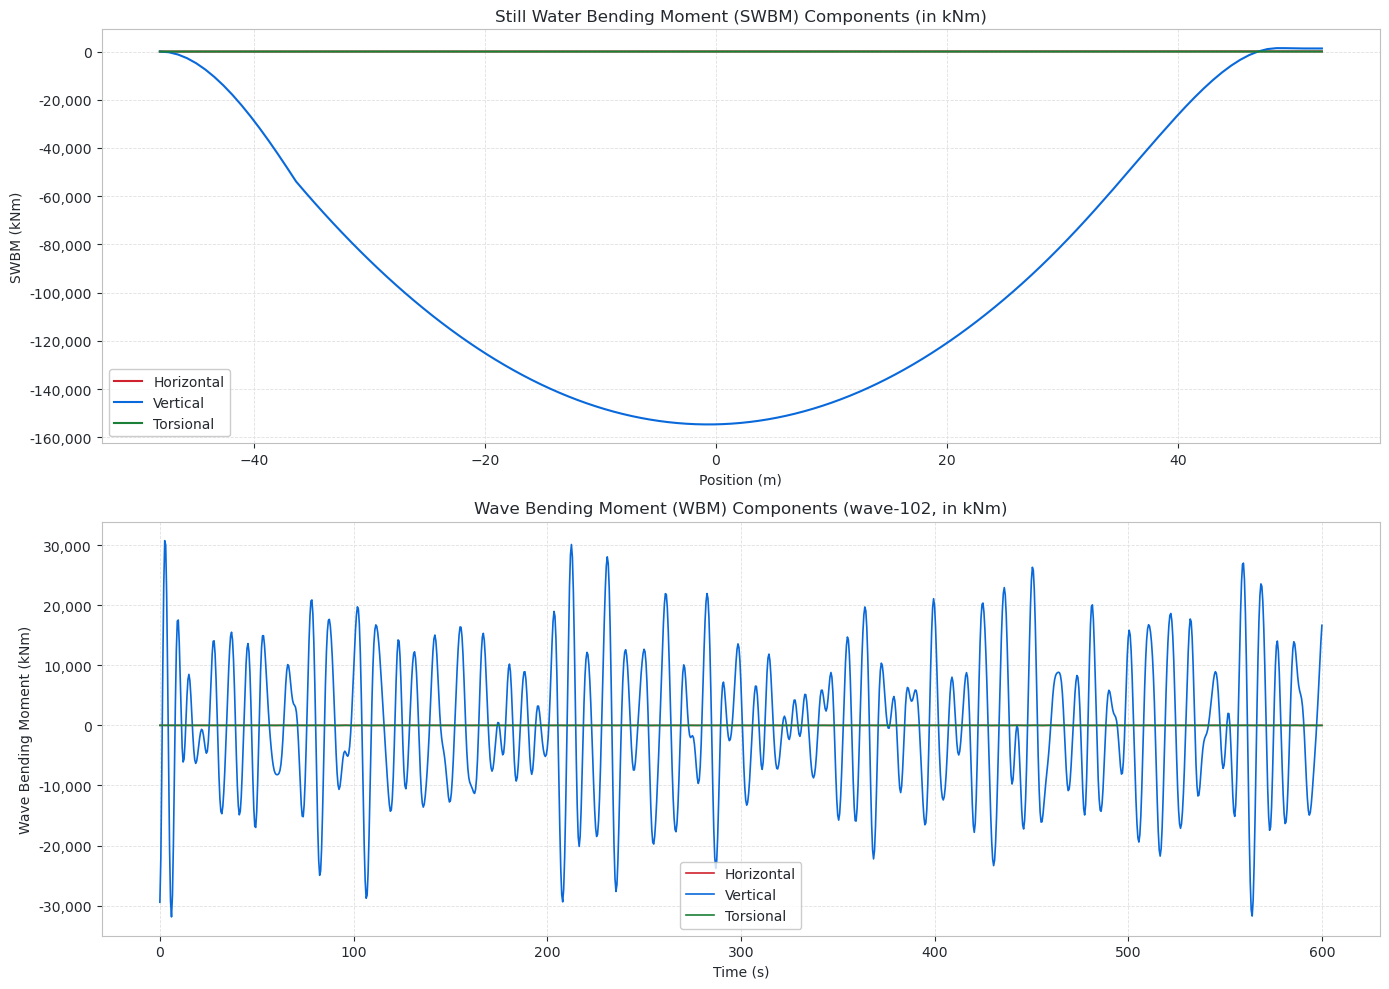

In [19]:
# Visualisasi semua komponen momen (Horizontal, Vertical, Torsional) untuk SWBM dan WBM (dalam kNm)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor(BG)

# Plot SWBM
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(df_swbm['Position (m)'], df_swbm['Horiontal SWBM (N.m)'] / 1000.0, label='Horizontal', color=COLORS['lat'], lw=1.5)
ax.plot(df_swbm['Position (m)'], df_swbm['Vertical SWBM (N.m)'] / 1000.0, label='Vertical', color=COLORS['vert'], lw=1.5)
ax.plot(df_swbm['Position (m)'], df_swbm['Torsional SWBM (N.m)'] / 1000.0, label='Torsional', color=COLORS['tors'], lw=1.5)
ax.set_xlabel('Position (m)')
ax.set_ylabel('SWBM (kNm)')
ax.set_title('Still Water Bending Moment (SWBM) Components (in kNm)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.legend(edgecolor=SPINE, facecolor=BG)
ax.grid(True)

# Plot WBM
ax = axes[1]
ax.set_facecolor(BG)
ax.plot(df_wbm['Time (s)'], df_wbm['Momen Horizontal (N.m)'] / 1000.0, label='Horizontal', color=COLORS['lat'], lw=1.2)
ax.plot(df_wbm['Time (s)'], df_wbm['Momen Vertikal (N.m)'] / 1000.0, label='Vertical', color=COLORS['vert'], lw=1.2)
ax.plot(df_wbm['Time (s)'], df_wbm['Momen Torsional (N.m)'] / 1000.0, label='Torsional', color=COLORS['tors'], lw=1.2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Wave Bending Moment (kNm)')
ax.set_title('Wave Bending Moment (WBM) Components (wave-102, in kNm)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.legend(edgecolor=SPINE, facecolor=BG)
ax.grid(True)

plt.tight_layout()
plt.show()

In [20]:
min_swbm_v = df_swbm['Vertical SWBM (N.m)'].min()
max_swbm_v = df_swbm['Vertical SWBM (N.m)'].max()
max_abs_swbm_v = max(abs(min_swbm_v), abs(max_swbm_v))

print(f"Minimum Vertical SWBM: {min_swbm_v:.4e} N.m ({min_swbm_v/1000.0:,.2f} kNm)")
print(f"Maximum Vertical SWBM: {max_swbm_v:.4e} N.m ({max_swbm_v/1000.0:,.2f} kNm)")
print(f"Absolute Maximum Vertical SWBM: {max_abs_swbm_v:.4e} N.m ({max_abs_swbm_v/1000.0:,.2f} kNm)")

# Jumlahkan absolute max SWBM ke semua nilai vertikal WBM
vbm_total = np.abs(df_wbm['Momen Vertikal (N.m)']) + max_abs_swbm_v

# Hitung mean & standar deviasi
mu_L = np.mean(vbm_total)
std_L = np.std(vbm_total, ddof=1)

print()
print("Statistik Beban Vertikal Total (VBM Total):")
print(f"Mean (mu_L)          : {mu_L:.4e} N.m ({mu_L/1000.0:,.2f} kNm)")
print(f"Std. Deviasi (sigma_L)  : {std_L:.4e} N.m ({std_L/1000.0:,.2f} kNm)")

Minimum Vertical SWBM: -1.5464e+08 N.m (-154,641.12 kNm)
Maximum Vertical SWBM: 1.4073e+06 N.m (1,407.32 kNm)
Absolute Maximum Vertical SWBM: 1.5464e+08 N.m (154,641.12 kNm)

Statistik Beban Vertikal Total (VBM Total):
Mean (mu_L)          : 1.6377e+08 N.m (163,768.35 kNm)
Std. Deviasi (sigma_L)  : 6.5511e+06 N.m (6,551.06 kNm)


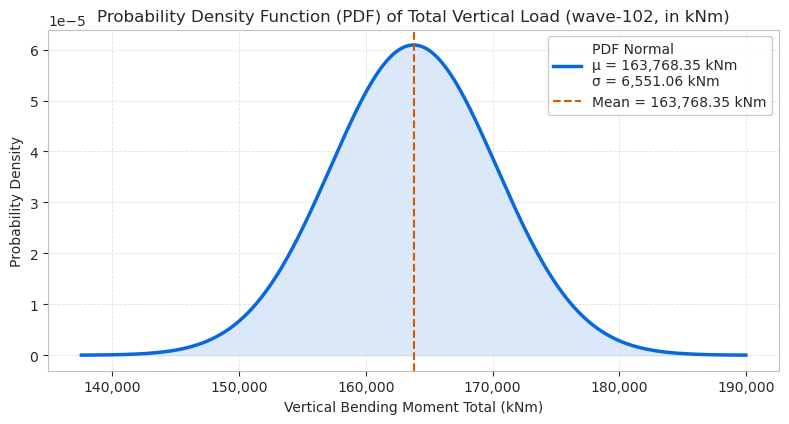

In [21]:
# Buat PDF untuk beban vertikal total (dalam kNm)
mu_L_knm = mu_L / 1000.0
std_L_knm = std_L / 1000.0
x_l = np.linspace(mu_L_knm - 4*std_L_knm, mu_L_knm + 4*std_L_knm, 1000)
pdf_L = norm.pdf(x_l, mu_L_knm, std_L_knm)

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.plot(x_l, pdf_L, color=COLORS['vert'], lw=2.5, label=f'PDF Normal\nμ = {mu_L_knm:,.2f} kNm\nσ = {std_L_knm:,.2f} kNm')
ax.fill_between(x_l, pdf_L, color=COLORS['vert'], alpha=0.15)
ax.axvline(mu_L_knm, color='#d15c00', ls='--', lw=1.5, label=f'Mean = {mu_L_knm:,.2f} kNm')
ax.set_xlabel('Vertical Bending Moment Total (kNm)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_ylabel('Probability Density')
ax.set_title('Probability Density Function (PDF) of Total Vertical Load (wave-102, in kNm)')
ax.legend(edgecolor=SPINE, facecolor=BG)
ax.grid(True)
plt.tight_layout()
plt.show()

## 2. Perhitungan Kekuatan (Strength Analysis) & Modulus dengan Faktor Korosi
Pada bagian ini, kita menghitung kekuatan section modulus deck dan bottom untuk variasi umur kapal $T \in [0, 10, 20, 30]$ tahun. Laju korosi diperoleh dari `cor-rate.csv` (menggunakan nilai rata-rata) dan dikonversi ke satuan cm/tahun. Korosi memengaruhi lebar ($b$) maupun tinggi ($h$) dari elemen scantling (bi-directional corrosion). Suffix 'Frame' pada scantling diinterpretasikan sebagai 'Flange' untuk pencocokan laju korosi. Modulus penampang terkecil di antara bottom dan deck di setiap tahun tinjauan dipilih sebagai governing modulus ($W_{\text{pantau}}$).

In [22]:
# Baca scantling data dan cor-rate data
df_scant = pd.read_csv('scantlling_rapi.csv', sep=';')
df_scant.columns = ['Nama Bagian', 'n', 'b', 'h', 'a', 'Z']
for col in ['n', 'b', 'h', 'a', 'Z']:
    df_scant[col] = pd.to_numeric(df_scant[col], errors='coerce')

df_cor = pd.read_csv('cor-rate.csv')

# Fungsi pemetaan elemen ke index cor-rate
def map_element(name):
    name_lower = name.lower()
    if 'pelat bottom' in name_lower or 'chine luar' in name_lower:
        return 'OPB'
    elif 'long stiff bottom' in name_lower or 'pembujur' in name_lower:
        if 'web' in name_lower:
            return 'SBW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SBF'
        else:
            return 'SBW'
    elif 'hopper dalam' in name_lower or 'inner bottom' in name_lower:
        return 'IPB'
    elif 'pelat deck' in name_lower:
        return 'DP'
    elif 'long stiff deck' in name_lower:
        if 'web' in name_lower:
            return 'DPW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'DPF'
        else:
            return 'DPW'
    elif 'sekat memanjang' in name_lower or 'sekat' in name_lower:
        if 'web' in name_lower:
            return 'SLW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SLF'
        else:
            return 'SLW'
    elif 'pelat sisi' in name_lower:
        return 'OPB'
    elif 'long stiff side shell' in name_lower or 'long stiff web' in name_lower or 'long stiff cl' in name_lower:
        if 'web' in name_lower:
            return 'SLW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SLF'
        else:
            return 'SLW'
    else:
        if 'web' in name_lower:
            return 'SLW'
        elif 'frame' in name_lower or 'flange' in name_lower:
            return 'SLF'
        else:
            return 'OPB'

df_scant['mapped_index'] = df_scant['Nama Bagian'].apply(map_element)
df_scant = df_scant.merge(df_cor, left_on='mapped_index', right_on='index', how='left')

print("Tabel Scantling dengan laju korosi yang dipetakan:")
display(df_scant[['Nama Bagian', 'mapped_index', 'μ (a) [mm/years]']].head(15))

Tabel Scantling dengan laju korosi yang dipetakan:


,Nama Bagian,mapped_index,μ (a) [mm/years]
0,Long Stiff Bottom 1 Web,SBW,0.1367
1,Long Stiff Bottom 1 Frame,SBF,0.1127
2,Long Stiff Bottom 2 Web,SBW,0.1367
3,Long Stiff Bottom 2 Frame,SBF,0.1127
4,Long Stiff Bottom 3 Web,SBW,0.1367
5,Long Stiff Bottom 3 Frame,SBF,0.1127
6,Long Stiff Bottom 4 Web,SBW,0.1367
7,Long Stiff Bottom 4 Frame,SBF,0.1127
8,Long Stiff Bottom 5 Web,SBW,0.1367
9,Long Stiff Bottom 5 Frame,SBF,0.1127


In [23]:
# Tinggi kapal (cm)
H_kapal = 609.6

def calculate_modulus_at_age(t):
    # Corrosion rate in cm/year (μ(a) / 10)
    corr_rate_cm = df_scant['μ (a) [mm/years]'] / 10.0
    
    # Korosi mempengaruhi lebar (b) dan tinggi (h) sekaligus
    b_aktual = np.clip(df_scant['b'] - corr_rate_cm * t, 0, None)
    h_aktual = np.clip(df_scant['h'] - corr_rate_cm * t, 0, None)
    
    a_rad = np.radians(df_scant['a'])
    
    A_T = df_scant['n'] * b_aktual * h_aktual
    S = A_T * df_scant['Z']
    S2 = A_T * df_scant['Z']**2
    
    Ix = (1/12) * b_aktual * h_aktual**3 * np.cos(a_rad)**2
    Iy = (1/12) * b_aktual * h_aktual**3 * np.sin(a_rad)**2
    I_ind = Ix + Iy
    
    Sigma1 = A_T.sum()
    Sigma2 = S.sum()
    Sigma3 = S2.sum()
    Sigma4 = I_ind.sum()
    
    Z1 = Sigma2 / Sigma1
    Z2 = H_kapal - Z1
    
    Ixx = Sigma3 + Sigma4
    I_NA = Ixx - (Z1**2) * Sigma1
    
    W_bot_cm = I_NA / Z1
    W_deck_cm = I_NA / Z2
    
    W_bot_m = W_bot_cm / 1e6
    W_deck_m = W_deck_cm / 1e6
    
    return W_bot_m, W_deck_m, Z1, Z2, I_NA

# Hitung modulus untuk variasi umur kapal
ages = [0, 10, 20, 30]
modulus_results = []
for t in ages:
    W_bot, W_deck, z1, z2, ina = calculate_modulus_at_age(t)
    W_pantau = min(W_bot, W_deck)
    modulus_results.append({
        'Age (years)': t,
        'W_bot (m³)': W_bot,
        'W_deck (m³)': W_deck,
        'W_pantau (m³)': W_pantau,
        'Z1 (cm)': z1,
        'Z2 (cm)': z2,
        'I_NA (cm⁴)': ina
    })

df_modulus = pd.DataFrame(modulus_results)
display(df_modulus)

,Age (years),W_bot (m³),W_deck (m³),W_pantau (m³),Z1 (cm),Z2 (cm),I_NA (cm⁴)
0,0,3.5287,3.2292,3.2292,291.2891,318.3109,1027875800.0177
1,10,3.3995,3.0895,3.0895,290.2382,319.3618,986656688.4800
2,20,3.2708,2.9508,2.9508,289.1231,320.4769,945663601.7019
3,30,3.1426,2.8132,2.8132,287.9399,321.6601,904888159.2993


### 2.2 Tabel Dimensi Scantling Hasil Korosi & Ekspor Data
Kita menyusun tabel scantling lengkap yang menunjukkan dimensi lebar ($b$) dan tinggi ($h$) untuk setiap umur peninjauan (0, 10, 20, dan 30 tahun), kemudian mengekspor tabel ini ke dalam file `scantling_corroded.csv`.

In [24]:
# Tambahkan kolom dimensi b dan h untuk tiap umur peninjauan ke dataframe scantling utama
corr_rate_cm = df_scant['μ (a) [mm/years]'] / 10.0

for t in [0, 10, 20, 30]:
    df_scant[f'b_t{t}'] = np.clip(df_scant['b'] - corr_rate_cm * t, 0, None)
    df_scant[f'h_t{t}'] = np.clip(df_scant['h'] - corr_rate_cm * t, 0, None)

print("Tabel scantling lengkap dengan dimensi terkorosi:")
display(df_scant.head(10))

# Ekspor ke file CSV
df_scant.to_csv('scantling_corroded.csv', sep=';', index=False)
print("Data scantling terkorosi berhasil diekspor ke 'scantling_corroded.csv'!")

Tabel scantling lengkap dengan dimensi terkorosi:


,Nama Bagian,n,b,h,a,Z,mapped_index,Structure element,μ (a) [mm/years],CoV (a),index,b_t0,h_t0,b_t10,h_t10,b_t20,h_t20,b_t30,h_t30
0,Long Stiff Bottom 1 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
1,Long Stiff Bottom 1 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
2,Long Stiff Bottom 2 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
3,Long Stiff Bottom 2 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
4,Long Stiff Bottom 3 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
5,Long Stiff Bottom 3 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
6,Long Stiff Bottom 4 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
7,Long Stiff Bottom 4 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619
8,Long Stiff Bottom 5 Web,2,0.9000,15.0000,0,7.5000,SBW,Outer bottom stiffener's web,0.1367,0.7802,SBW,0.9000,15.0000,0.7633,14.8633,0.6266,14.7266,0.4899,14.5899
9,Long Stiff Bottom 5 Frame,2,8.1000,0.9000,0,0.4500,SBF,Outer bottom stiffener's flange,0.1127,1.0121,SBF,8.1000,0.9000,7.9873,0.7873,7.8746,0.6746,7.7619,0.5619


Data scantling terkorosi berhasil diekspor ke 'scantling_corroded.csv'!


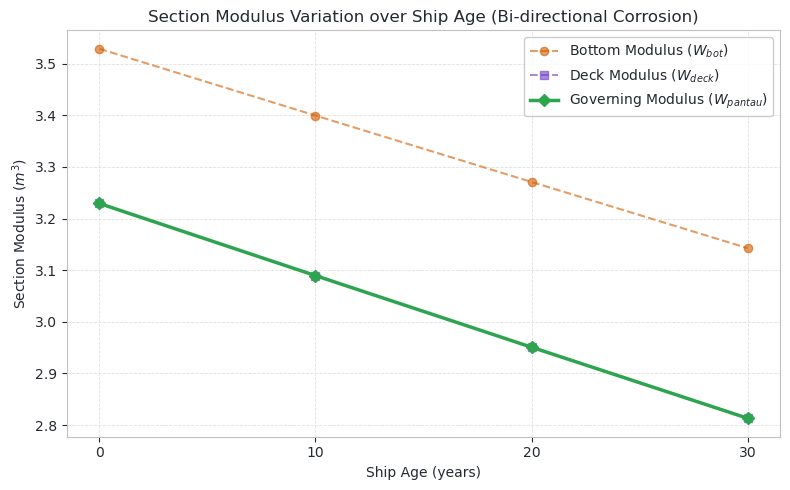

In [25]:
# Plot variasi W_pantau, W_bot, dan W_deck over time
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(df_modulus['Age (years)'], df_modulus['W_bot (m³)'], color=COLORS['bot'], marker='o', ls='--', label=r'Bottom Modulus ($W_{bot}$)', alpha=0.6)
ax.plot(df_modulus['Age (years)'], df_modulus['W_deck (m³)'], color=COLORS['deck'], marker='s', ls='--', label=r'Deck Modulus ($W_{deck}$)', alpha=0.6)
ax.plot(df_modulus['Age (years)'], df_modulus['W_pantau (m³)'], color=COLORS['pantau'], marker='D', ls='-', lw=2.5, label=r'Governing Modulus ($W_{pantau}$)', zorder=4)

ax.set_xlabel('Ship Age (years)')
ax.set_ylabel(r'Section Modulus ($m^3$)')
ax.set_title('Section Modulus Variation over Ship Age (Bi-directional Corrosion)')
ax.set_xticks(ages)
ax.legend(edgecolor=SPINE, facecolor=BG)
ax.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Data A36 Ultimate Strength (MPa)
data_strength = np.array([
    355.504, 439.795, 472.011, 263.955, 376.981, 342.362,
    478.974, 484.172, 485.152,
    360.7, 400.4, 468.2, 426.9, 363.9, 391.1,
    462.3, 435.7, 355.7, 401.1, 472.0, 418.0
])

mu_Y = np.mean(data_strength)
std_Y = np.std(data_strength, ddof=1)

print("Statistik Kekuatan Material (A36 Ultimate Tensile Strength):")
print(f"Rata-rata (μ_Y)     : {mu_Y:.4f} MPa")
print(f"Std. Deviasi (σ_Y)  : {std_Y:.4f} MPa")

Statistik Kekuatan Material (A36 Ultimate Tensile Strength):
Rata-rata (μ_Y)     : 412.1384 MPa
Std. Deviasi (σ_Y)  : 58.9565 MPa


## 3. Analisis Keandalan (Reliability Analysis) dalam Satuan MPa
Analisis keandalan dilakukan sepenuhnya dalam satuan tegangan (MPa). Momen beban lentur total dikonversi menjadi tegangan (MPa) menggunakan governing section modulus ($W_{\text{pantau}}$):

$$\sigma_L = \frac{VBM_{\text{total}}}{W_{\text{pantau}}} \times 10^{-6}$$

Statistik tegangan beban menjadi:
- $\mu_{\sigma_L} = \frac{\mu_L}{W_{\text{pantau}}} \times 10^{-6}$
- $\sigma_{\sigma_L} = \frac{\sigma_L}{W_{\text{pantau}}} \times 10^{-6}$

Kita menghitung:
- **Safety Factor (FoS):** $FOS = \mu_Y / \mu_{\sigma_L}$
- **Safety Index ($\beta$):** $\beta = \frac{\mu_Y - \mu_{\sigma_L}}{\sqrt{\sigma_Y^2 + \sigma_{\sigma_L}^2}}$
- **Failure Probability ($P_f$):** dihitung secara analitis $\Phi(-\beta)$ dan numerik melalui konvolusi integral.

In [27]:
reliability_results = []

for row in modulus_results:
    t = row['Age (years)']
    W_pantau = row['W_pantau (m³)']
    
    # Konversi beban ke MPa
    mu_sigma_L = (mu_L / W_pantau) * 1e-6
    sigma_sigma_L = (std_L / W_pantau) * 1e-6
    
    # Safety Factor (FoS)
    FoS = mu_Y / mu_sigma_L
    
    # Safety Index (Beta)
    beta = (mu_Y - mu_sigma_L) / np.sqrt(std_Y**2 + sigma_sigma_L**2)
    
    # Failure Probability (Pf) - Analitis
    pf_analytical = norm.cdf(-beta)
    
    # Failure Probability (Pf) - Konvolusi Numerik
    integrand = lambda x: norm.pdf(x, mu_sigma_L, sigma_sigma_L) * norm.cdf(x, mu_Y, std_Y)
    limit_low = mu_sigma_L - 8 * sigma_sigma_L
    limit_high = mu_sigma_L + 8 * sigma_sigma_L
    pf_numerical, _ = quad(integrand, limit_low, limit_high)
    
    reliability_results.append({
        'Age (years)': t,
        'W_pantau (m³)': W_pantau,
        'mu_sigma_L (MPa)': mu_sigma_L,
        'sigma_sigma_L (MPa)': sigma_sigma_L,
        'FoS': FoS,
        'Beta': beta,
        'Pf_analytical': pf_analytical,
        'Pf_numerical': pf_numerical,
        'R_numerical': 1.0 - pf_numerical
    })

df_rel = pd.DataFrame(reliability_results)
display(df_rel)

,Age (years),W_pantau (m³),mu_sigma_L (MPa),sigma_sigma_L (MPa),FoS,Beta,Pf_analytical,Pf_numerical,R_numerical
0,0,3.2292,50.7155,2.0287,8.1265,6.1267,0.0000,0.0000,1.0000
1,10,3.0895,53.0087,2.1205,7.7749,6.0875,0.0000,0.0000,1.0000
2,20,2.9508,55.4996,2.2201,7.4260,6.0449,0.0000,0.0000,1.0000
3,30,2.8132,58.2146,2.3287,7.0796,5.9985,0.0000,0.0000,1.0000


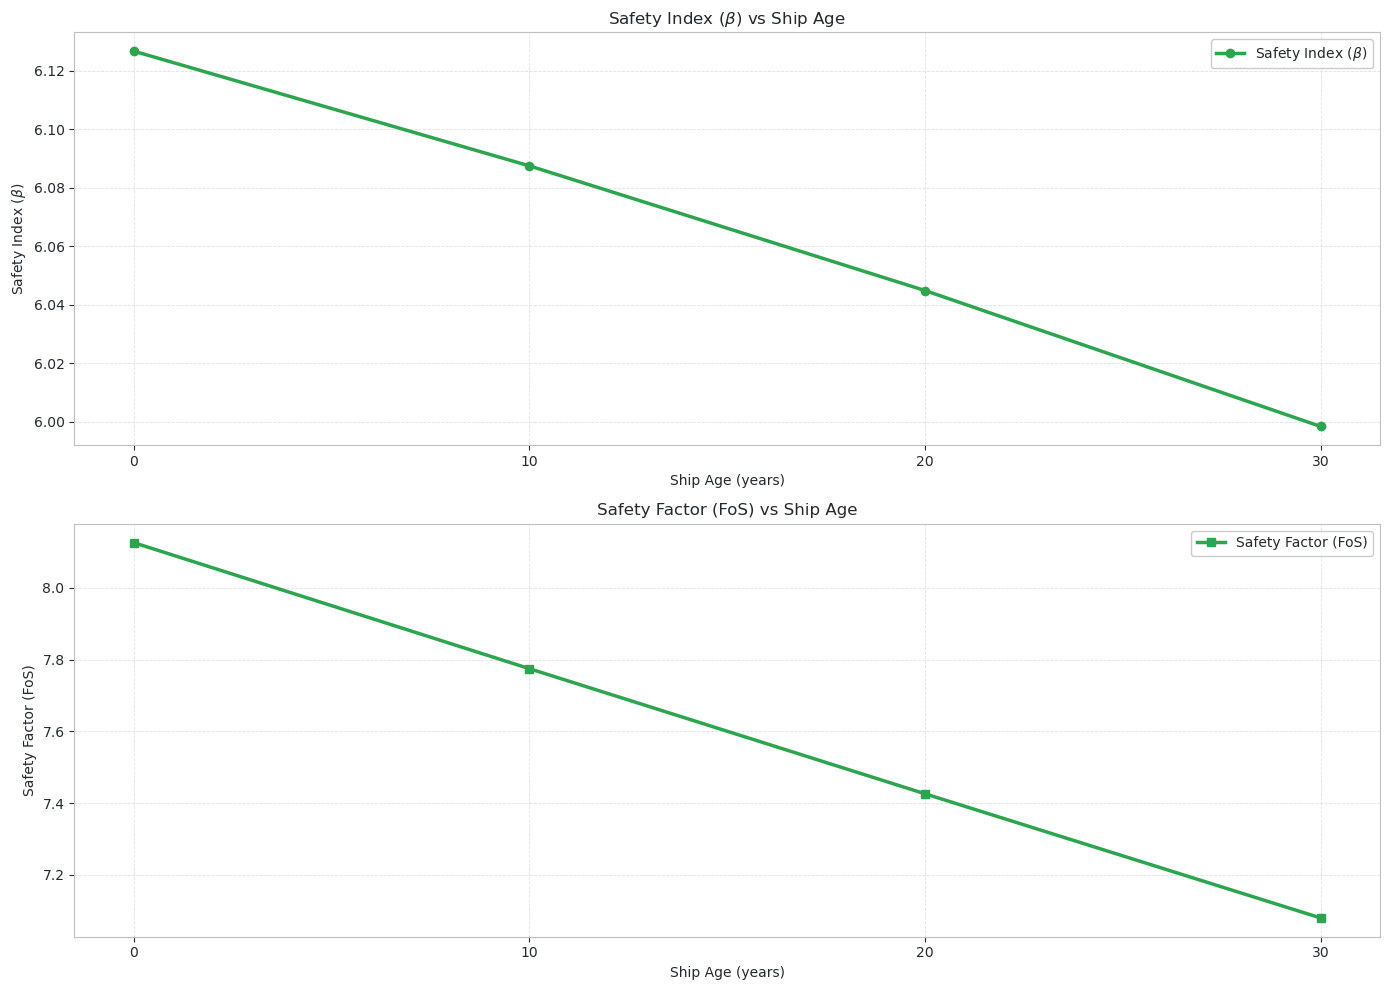

In [28]:
# Plot perbandingan Safety Index & Safety Factor vs Umur Kapal
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor(BG)

# Plot Safety Index (Beta)
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(df_rel['Age (years)'], df_rel['Beta'], color=COLORS['pantau'], marker='o', lw=2.5, label=r'Safety Index ($\beta$)')
ax.set_xlabel('Ship Age (years)', fontsize=10)
ax.set_ylabel(r'Safety Index ($\beta$)', fontsize=10)
ax.set_title(r'Safety Index ($\beta$) vs Ship Age')
ax.set_xticks(ages)
ax.grid(True)
ax.legend(edgecolor=SPINE, facecolor=BG)

# Plot Safety Factor (FoS)
ax = axes[1]
ax.set_facecolor(BG)
ax.plot(df_rel['Age (years)'], df_rel['FoS'], color=COLORS['pantau'], marker='s', lw=2.5, label='Safety Factor (FoS)')
ax.set_xlabel('Ship Age (years)', fontsize=10)
ax.set_ylabel('Safety Factor (FoS)', fontsize=10)
ax.set_title('Safety Factor (FoS) vs Ship Age')
ax.set_xticks(ages)
ax.grid(True)
ax.legend(edgecolor=SPINE, facecolor=BG)

plt.tight_layout()
plt.show()

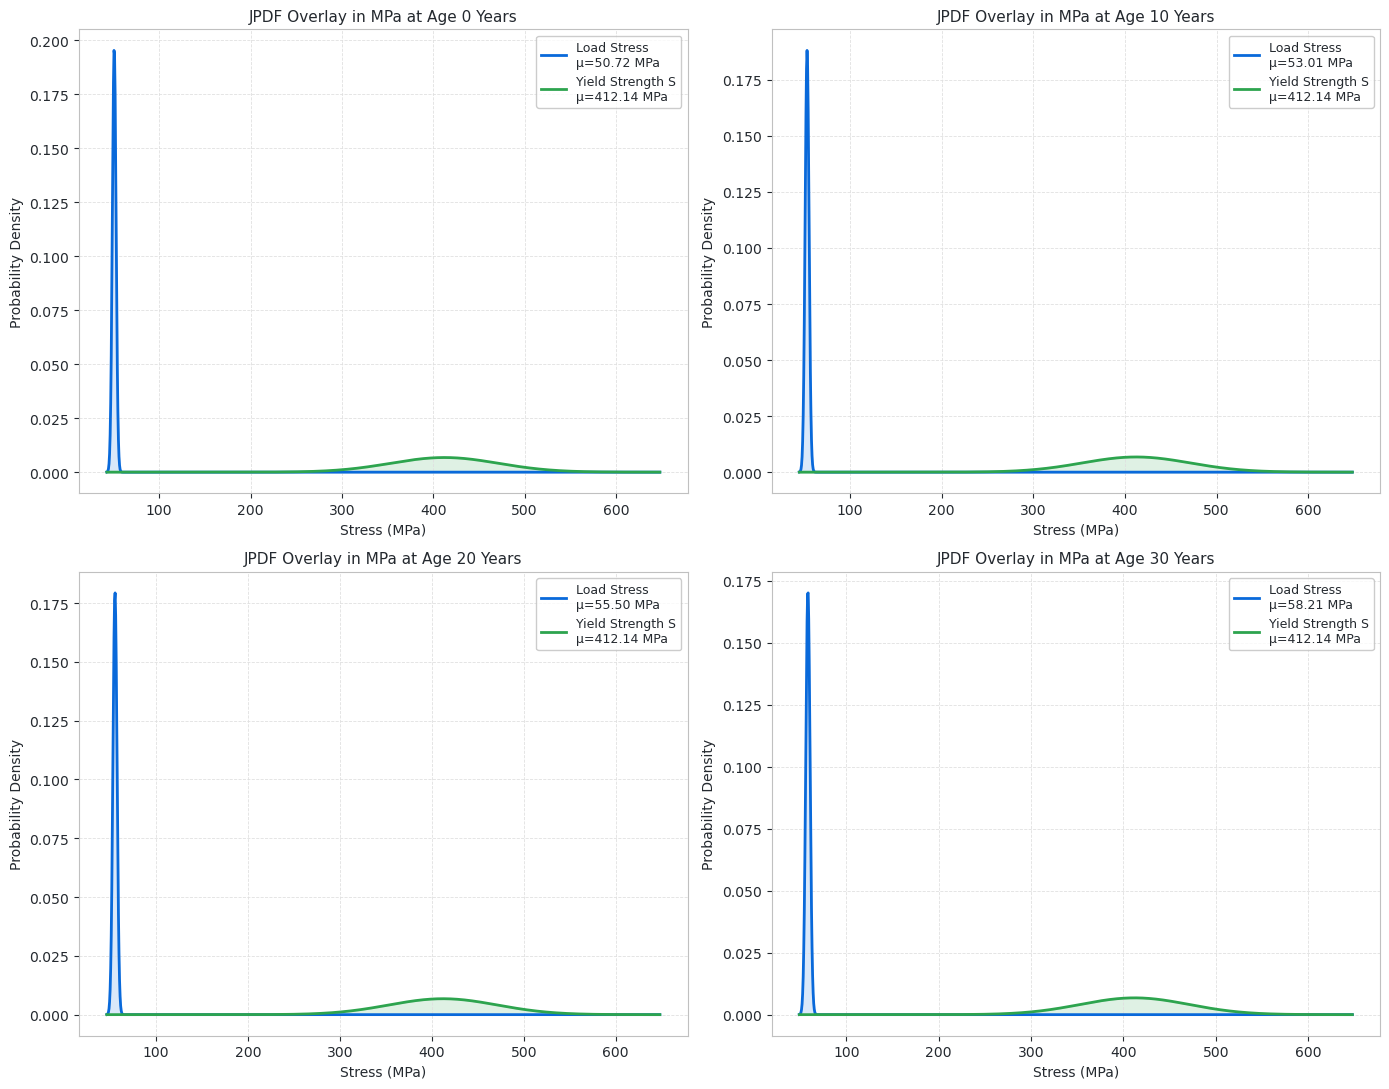

In [29]:
# Plot JPDF (Overlay PDF) antara Beban Stress dan Kekuatan Stress (MPa) untuk 4 umur
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for ax, t in zip(axes, ages):
    ax.set_facecolor(BG)
    row = df_rel[df_rel['Age (years)'] == t].iloc[0]
    mu_s_L = row['mu_sigma_L (MPa)']
    std_s_L = row['sigma_sigma_L (MPa)']
    
    # Tentukan range plotting x (MPa)
    lo = min(mu_Y - 4*std_Y, mu_s_L - 4*std_s_L)
    hi = max(mu_Y + 4*std_Y, mu_s_L + 4*std_s_L)
    x = np.linspace(lo, hi, 1000)
    
    # PDF Load Stress
    pdf_load = norm.pdf(x, mu_s_L, std_s_L)
    ax.plot(x, pdf_load, color=COLORS['vert'], lw=2, label=f'Load Stress\nμ={mu_s_L:.2f} MPa')
    ax.fill_between(x, pdf_load, color=COLORS['vert'], alpha=0.15)
    
    # PDF Strength Stress
    pdf_strength = norm.pdf(x, mu_Y, std_Y)
    ax.plot(x, pdf_strength, color=COLORS['pantau'], lw=2, label=f'Yield Strength S\nμ={mu_Y:.2f} MPa')
    ax.fill_between(x, pdf_strength, color=COLORS['pantau'], alpha=0.15)
    
    ax.set_title(f'JPDF Overlay in MPa at Age {t} Years', fontsize=11)
    ax.set_xlabel('Stress (MPa)', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)
    ax.legend(fontsize=9, edgecolor=SPINE, facecolor=BG)
    ax.grid(True)

plt.tight_layout()
plt.show()

## 4. Analisis Keandalan Menggunakan Yield Strength Baja A36 (250 MPa)
Pada tahap ini, kita melakukan analisis keandalan ulang menggunakan nilai rata-rata Yield Strength baja A36 sebesar **250 MPa**. 
Standard deviasi untuk yield strength dicari dengan mempertahankan Koefisien Variasi (CoV) dari data kekuatan ultimate sebelumnya:

$$\text{CoV} = \frac{\sigma_{Y\_ultimate}}{\mu_{Y\_ultimate}}$$
$$\sigma_{Y\_new} = \mu_{Y\_new} \times \text{CoV}$$

Kita menghitung kembali Safety Factor, Safety Index ($\beta$), dan JPDF Overlay untuk kasus Yield Strength ini.

In [30]:
# Hitung CoV dari data ultimate strength
cov_Y = std_Y / mu_Y

# Definisikan parameter yield strength baru
mu_Y_yield = 250.0
std_Y_yield = mu_Y_yield * cov_Y

print(f"Koefisien Variasi (CoV) Ultimate Strength: {cov_Y:.6f}")
print(f"Yield Strength Baru - Rata-rata (μ_Y) : {mu_Y_yield:.2f} MPa")
print(f"Yield Strength Baru - Std. Deviasi (σ_Y): {std_Y_yield:.6f} MPa\n")

reliability_yield_results = []

for row in modulus_results:
    t = row['Age (years)']
    W_pantau = row['W_pantau (m³)']
    
    # Konversi beban ke MPa
    mu_sigma_L = (mu_L / W_pantau) * 1e-6
    sigma_sigma_L = (std_L / W_pantau) * 1e-6
    
    # Safety Factor (FoS)
    FoS = mu_Y_yield / mu_sigma_L
    
    # Safety Index (Beta)
    beta = (mu_Y_yield - mu_sigma_L) / np.sqrt(std_Y_yield**2 + sigma_sigma_L**2)
    
    # Failure Probability (Pf) - Analitis
    pf_analytical = norm.cdf(-beta)
    
    # Failure Probability (Pf) - Konvolusi Numerik
    integrand = lambda x: norm.pdf(x, mu_sigma_L, sigma_sigma_L) * norm.cdf(x, mu_Y_yield, std_Y_yield)
    limit_low = mu_sigma_L - 8 * sigma_sigma_L
    limit_high = mu_sigma_L + 8 * sigma_sigma_L
    pf_numerical, _ = quad(integrand, limit_low, limit_high)
    
    reliability_yield_results.append({
        'Age (years)': t,
        'W_pantau (m³)': W_pantau,
        'mu_sigma_L (MPa)': mu_sigma_L,
        'sigma_sigma_L (MPa)': sigma_sigma_L,
        'FoS': FoS,
        'Beta': beta,
        'Pf_analytical': pf_analytical,
        'Pf_numerical': pf_numerical,
        'R_numerical': 1.0 - pf_numerical
    })

df_rel_yield = pd.DataFrame(reliability_yield_results)
display(df_rel_yield)

Koefisien Variasi (CoV) Ultimate Strength: 0.143050
Yield Strength Baru - Rata-rata (μ_Y) : 250.00 MPa
Yield Strength Baru - Std. Deviasi (σ_Y): 35.762546 MPa



,Age (years),W_pantau (m³),mu_sigma_L (MPa),sigma_sigma_L (MPa),FoS,Beta,Pf_analytical,Pf_numerical,R_numerical
0,0,3.2292,50.7155,2.0287,4.9295,5.5635,0.0000,0.0000,1.0000
1,10,3.0895,53.0087,2.1205,4.7162,5.4987,0.0000,0.0000,1.0000
2,20,2.9508,55.4996,2.2201,4.5045,5.4282,0.0000,0.0000,1.0000
3,30,2.8132,58.2146,2.3287,4.2945,5.3514,0.0000,0.0000,1.0000


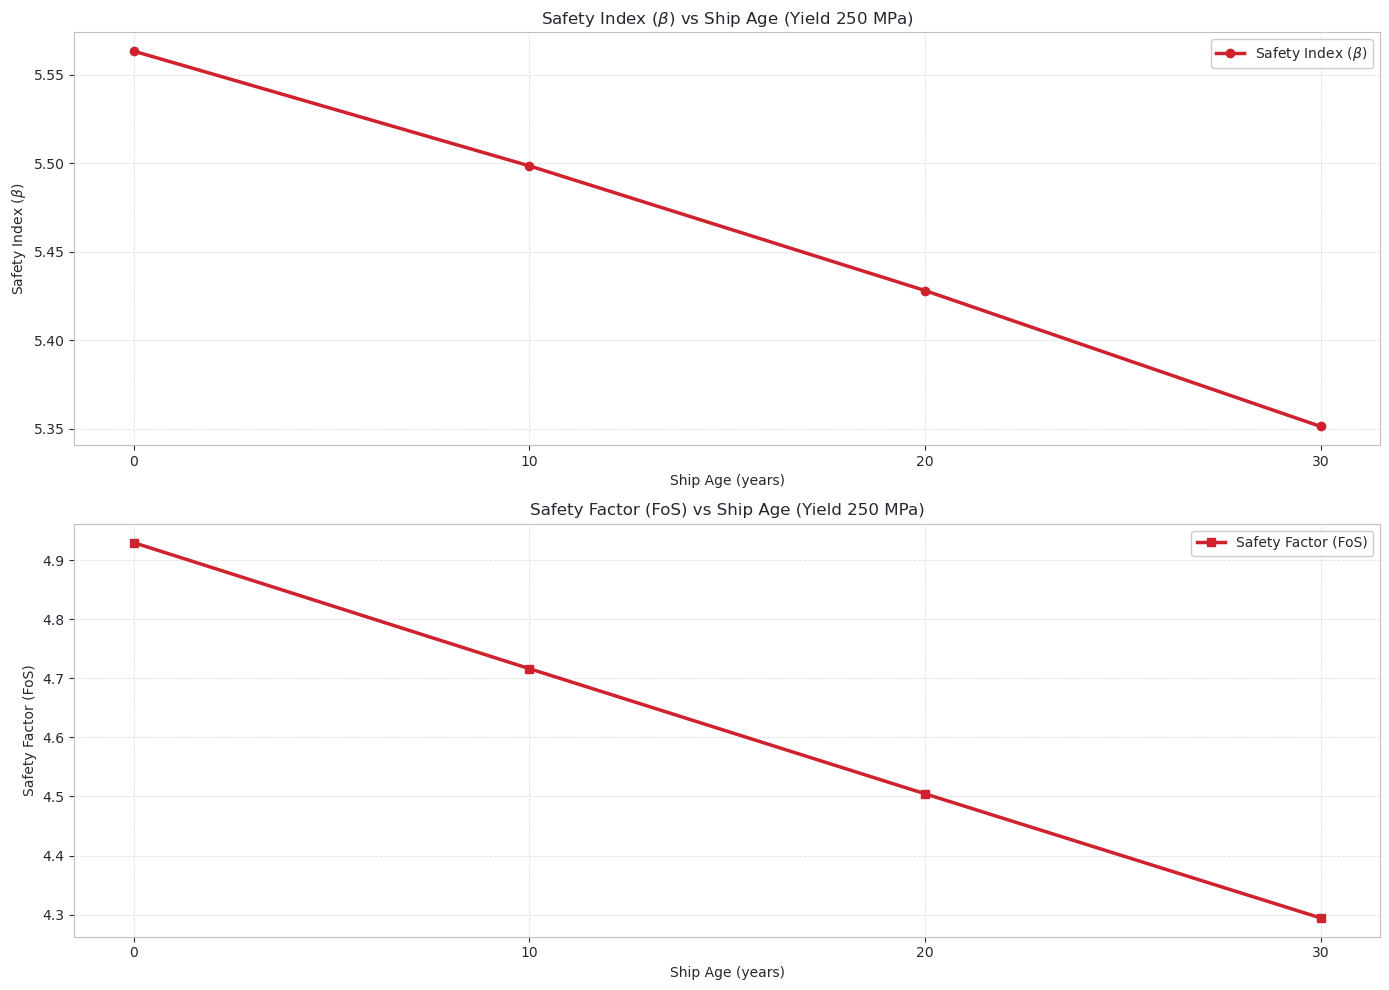

In [31]:
# Plot perbandingan Safety Index & Safety Factor vs Umur Kapal (Kasus Yield Strength = 250 MPa)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor(BG)

# Plot Safety Index (Beta)
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(df_rel_yield['Age (years)'], df_rel_yield['Beta'], color=COLORS['lat'], marker='o', lw=2.5, label=r'Safety Index ($\beta$)')
ax.set_xlabel('Ship Age (years)', fontsize=10)
ax.set_ylabel(r'Safety Index ($\beta$)', fontsize=10)
ax.set_title(r'Safety Index ($\beta$) vs Ship Age (Yield 250 MPa)')
ax.set_xticks(ages)
ax.grid(True)
ax.legend(edgecolor=SPINE, facecolor=BG)

# Plot Safety Factor (FoS)
ax = axes[1]
ax.set_facecolor(BG)
ax.plot(df_rel_yield['Age (years)'], df_rel_yield['FoS'], color=COLORS['lat'], marker='s', lw=2.5, label='Safety Factor (FoS)')
ax.set_xlabel('Ship Age (years)', fontsize=10)
ax.set_ylabel('Safety Factor (FoS)', fontsize=10)
ax.set_title('Safety Factor (FoS) vs Ship Age (Yield 250 MPa)')
ax.set_xticks(ages)
ax.grid(True)
ax.legend(edgecolor=SPINE, facecolor=BG)

plt.tight_layout()
plt.show()

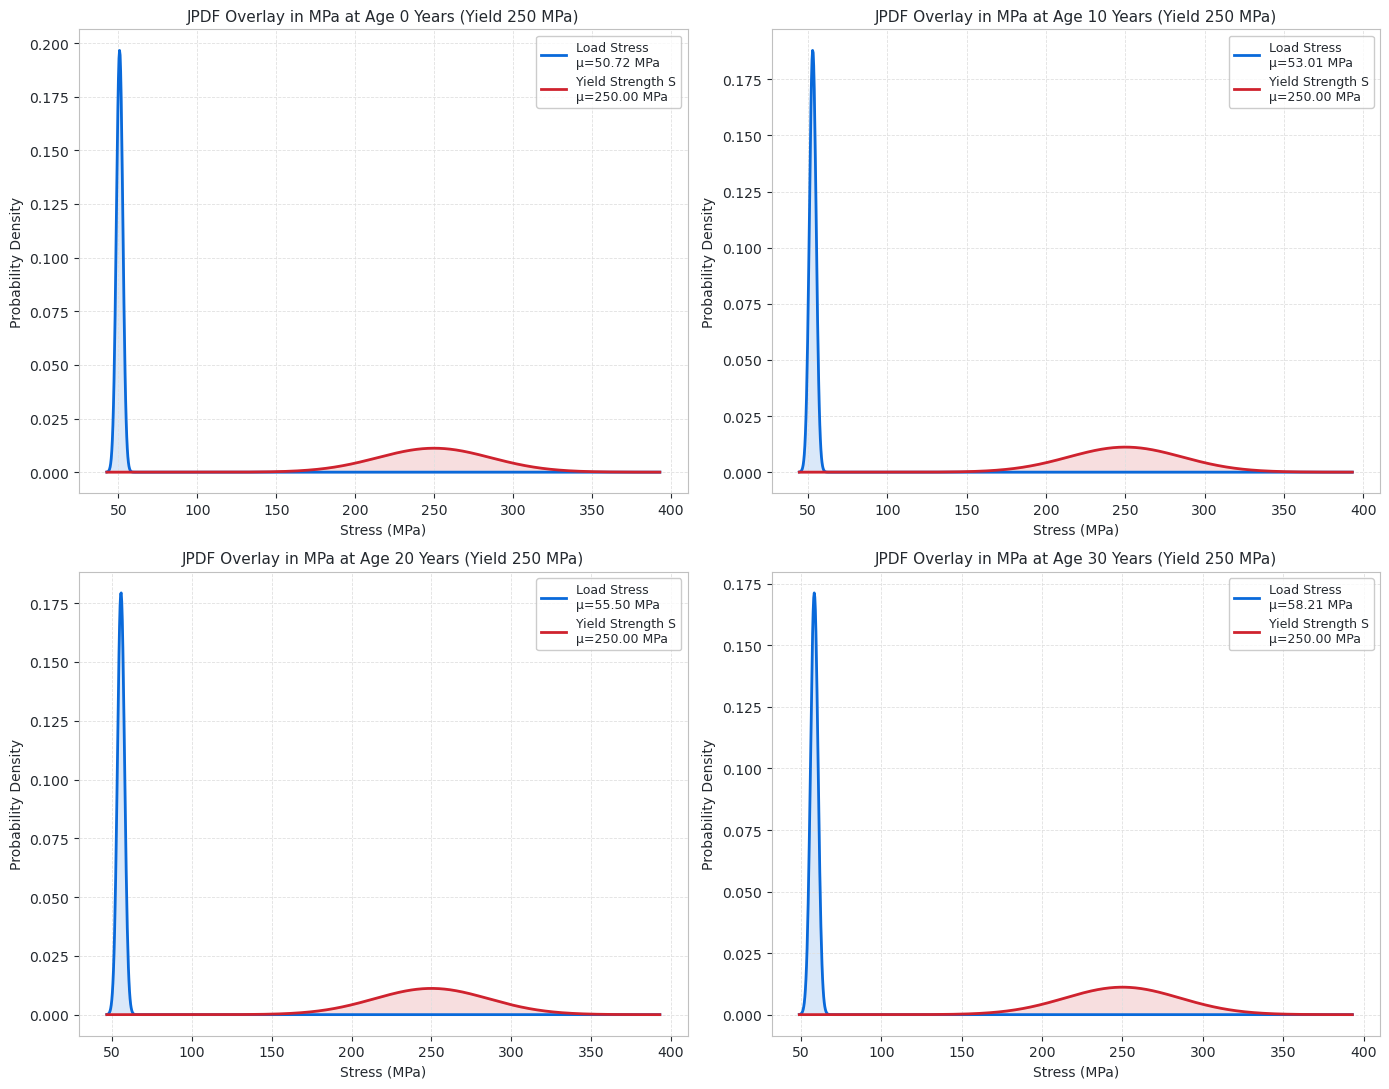

In [32]:
# Plot JPDF (Overlay PDF) antara Beban Stress dan Kekuatan Stress (MPa) untuk Yield Strength 250 MPa
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for ax, t in zip(axes, ages):
    ax.set_facecolor(BG)
    row = df_rel_yield[df_rel_yield['Age (years)'] == t].iloc[0]
    mu_s_L = row['mu_sigma_L (MPa)']
    std_s_L = row['sigma_sigma_L (MPa)']
    
    # Tentukan range plotting x (MPa)
    lo = min(mu_Y_yield - 4*std_Y_yield, mu_s_L - 4*std_s_L)
    hi = max(mu_Y_yield + 4*std_Y_yield, mu_s_L + 4*std_s_L)
    x = np.linspace(lo, hi, 1000)
    
    # PDF Load Stress
    pdf_load = norm.pdf(x, mu_s_L, std_s_L)
    ax.plot(x, pdf_load, color=COLORS['vert'], lw=2, label=f'Load Stress\nμ={mu_s_L:.2f} MPa')
    ax.fill_between(x, pdf_load, color=COLORS['vert'], alpha=0.15)
    
    # PDF Strength Stress (Yield)
    pdf_strength = norm.pdf(x, mu_Y_yield, std_Y_yield)
    ax.plot(x, pdf_strength, color=COLORS['lat'], lw=2, label=f'Yield Strength S\nμ={mu_Y_yield:.2f} MPa')
    ax.fill_between(x, pdf_strength, color=COLORS['lat'], alpha=0.15)
    
    ax.set_title(f'JPDF Overlay in MPa at Age {t} Years (Yield 250 MPa)', fontsize=11)
    ax.set_xlabel('Stress (MPa)', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)
    ax.legend(fontsize=9, edgecolor=SPINE, facecolor=BG)
    ax.grid(True)

plt.tight_layout()
plt.show()